# 14 — Underwriting Decision Model

## Business objective

Build a model that provides **underwriting decision support** for:

- `Approved`
- `Approved with Loading`
- `Declined`

The model is **not the final underwriting authority**.  
`Approved with Loading` and `Declined` recommendations should later be routed to **human underwriting review**.

## Leakage rules

We deliberately exclude:

- `DECISION` → target
- `UNDERWRITING_SCORE` → in this synthetic data it almost deterministically defines the decision
- `PREMIUM_LOADING_PCT` → outcome of the underwriting decision

The model therefore learns from risk information that would plausibly be available before the final decision.

In [1]:
# Run only if required:
# %pip install pandas numpy matplotlib scikit-learn xgboost joblib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    LabelEncoder,
)

from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Resolve project paths

In [3]:
CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "data" / "raw").exists():
    PROJECT_DIR = CURRENT_DIR

elif (CURRENT_DIR.parent / "data" / "raw").exists():
    PROJECT_DIR = CURRENT_DIR.parent

else:
    raise FileNotFoundError(
        "Could not locate project root. "
        "Expected data/raw under current folder or parent folder."
    )

RAW_DIR = PROJECT_DIR / "data" / "raw"
CURATED_DIR = PROJECT_DIR / "data" / "curated"
MODELS_DIR = PROJECT_DIR / "models"

CURATED_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR :", PROJECT_DIR)
print("RAW_DIR     :", RAW_DIR)
print("MODELS_DIR  :", MODELS_DIR)

PROJECT_DIR : f:\insurance_ai_copilot
RAW_DIR     : f:\insurance_ai_copilot\data\raw
MODELS_DIR  : f:\insurance_ai_copilot\models


## 2. Load underwriting data

In [4]:
underwriting_df = pd.read_csv(
    RAW_DIR / "underwriting.csv"
)

print(
    "Underwriting shape:",
    underwriting_df.shape
)

display(
    underwriting_df.head()
)

Underwriting shape: (50000, 14)


,UNDERWRITING_ID,POLICY_ID,CUSTOMER_ID,AGE,HEALTH_SCORE,LIFESTYLE,MEDICAL_HISTORY_FLAG,SMOKER_FLAG,BMI,OCCUPATION_RISK,CREDIT_SCORE,UNDERWRITING_SCORE,DECISION,PREMIUM_LOADING_PCT
0,UW00000001,POL000075805,CUST00024107,37,63,Good,No,No,26.0,Medium,789,489,Approved with Loading,18.44
1,UW00000002,POL000061636,CUST00009702,37,86,Excellent,No,Yes,27.5,Medium,616,653,Approved,0.00
2,UW00000003,POL000109448,CUST00044764,38,86,Average,No,No,31.6,Low,701,620,Approved,0.00
3,UW00000004,POL000003539,CUST00099336,20,81,Good,No,No,29.3,Low,739,630,Approved,0.00
4,UW00000005,POL000023463,CUST00035999,49,76,Good,No,No,22.6,Low,630,626,Approved,0.00


## 3. Validate expected schema

In [5]:
required_cols = [
    "UNDERWRITING_ID",
    "POLICY_ID",
    "CUSTOMER_ID",
    "AGE",
    "HEALTH_SCORE",
    "LIFESTYLE",
    "MEDICAL_HISTORY_FLAG",
    "SMOKER_FLAG",
    "BMI",
    "OCCUPATION_RISK",
    "CREDIT_SCORE",
    "UNDERWRITING_SCORE",
    "DECISION",
    "PREMIUM_LOADING_PCT",
]

missing_cols = [
    col
    for col in required_cols
    if col not in underwriting_df.columns
]

print(
    "Missing columns:",
    missing_cols
)

assert not missing_cols, (
    f"Underwriting schema mismatch. Missing: {missing_cols}"
)

Missing columns: []


## 4. Check target distribution

In [6]:
decision_summary = (
    underwriting_df[
        "DECISION"
    ]
    .value_counts()
    .to_frame(
        "COUNT"
    )
)

decision_summary[
    "PCT"
] = (
    decision_summary[
        "COUNT"
    ]
    /
    len(
        underwriting_df
    )
    * 100
).round(2)

display(
    decision_summary
)

,COUNT,PCT
DECISION,,
Approved,41717,83.43
Approved with Loading,6746,13.49
Declined,1537,3.07


### Why this is a multiclass problem

The target has three business outcomes:

- `Approved`
- `Approved with Loading`
- `Declined`

The minority class (`Declined`) is much smaller, so we will inspect **macro F1** and **balanced accuracy**, not only overall accuracy.

## 5. Define leakage-safe features

In [7]:
numeric_features = [
    "AGE",
    "HEALTH_SCORE",
    "BMI",
    "CREDIT_SCORE",
]

categorical_features = [
    "LIFESTYLE",
    "MEDICAL_HISTORY_FLAG",
    "SMOKER_FLAG",
    "OCCUPATION_RISK",
]

all_features = (
    numeric_features
    +
    categorical_features
)

excluded_leakage_cols = [
    "DECISION",
    "UNDERWRITING_SCORE",
    "PREMIUM_LOADING_PCT",
]

missing_features = [
    col
    for col in all_features
    if col not in underwriting_df.columns
]

print(
    "Missing model features:",
    missing_features
)

assert not missing_features, (
    f"Missing model features: {missing_features}"
)

print(
    "Model features:",
    all_features
)

print(
    "Excluded leakage fields:",
    excluded_leakage_cols
)

Missing model features: []
Model features: ['AGE', 'HEALTH_SCORE', 'BMI', 'CREDIT_SCORE', 'LIFESTYLE', 'MEDICAL_HISTORY_FLAG', 'SMOKER_FLAG', 'OCCUPATION_RISK']
Excluded leakage fields: ['DECISION', 'UNDERWRITING_SCORE', 'PREMIUM_LOADING_PCT']


## 6. Encode target labels

In [8]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(
    underwriting_df[
        "DECISION"
    ]
)

print(
    "Encoded classes:"
)

for class_id, class_name in enumerate(
    label_encoder.classes_
):
    print(
        class_id,
        "->",
        class_name
    )

Encoded classes:
0 -> Approved
1 -> Approved with Loading
2 -> Declined


In [9]:
X = underwriting_df[
    all_features
].copy()

print(
    "X shape:",
    X.shape
)

print(
    "y shape:",
    y.shape
)

X shape: (50000, 8)
y shape: (50000,)


## 7. Train / test split

In [10]:
X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y,
    )
)

print(
    "Train rows:",
    len(X_train)
)

print(
    "Test rows:",
    len(X_test)
)

Train rows: 40000
Test rows: 10000


## 8. Build preprocessing pipeline

In [11]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        ),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        ),
    ]
)

print(
    "Preprocessor created."
)

Preprocessor created.


## 9. Reusable evaluation function

In [12]:
def evaluate_multiclass_model(
    name,
    model,
    X_test,
    y_test,
    label_encoder,
):

    predictions = model.predict(
        X_test
    )

    metrics = {
        "MODEL":
            name,

        "ACCURACY":
            accuracy_score(
                y_test,
                predictions
            ),

        "BALANCED_ACCURACY":
            balanced_accuracy_score(
                y_test,
                predictions
            ),

        "MACRO_PRECISION":
            precision_score(
                y_test,
                predictions,
                average="macro",
                zero_division=0
            ),

        "MACRO_RECALL":
            recall_score(
                y_test,
                predictions,
                average="macro",
                zero_division=0
            ),

        "MACRO_F1":
            f1_score(
                y_test,
                predictions,
                average="macro",
                zero_division=0
            ),

        "WEIGHTED_F1":
            f1_score(
                y_test,
                predictions,
                average="weighted",
                zero_division=0
            ),
    }

    print(
        "\n"
        + "=" * 70
    )

    print(name)

    print(
        "=" * 70
    )

    for key, value in metrics.items():

        if key != "MODEL":

            print(
                f"{key}:",
                round(
                    value,
                    4
                )
            )

    print(
        "\nConfusion Matrix:"
    )

    print(
        confusion_matrix(
            y_test,
            predictions
        )
    )

    print(
        "\nClassification Report:"
    )

    print(
        classification_report(
            y_test,
            predictions,
            target_names=
                label_encoder.classes_,
            zero_division=0
        )
    )

    return metrics

## 10. Dummy baseline

In [13]:
dummy_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            DummyClassifier(
                strategy="most_frequent"
            )
        ),
    ]
)

dummy_pipeline.fit(
    X_train,
    y_train
)

_ = evaluate_multiclass_model(
    "Dummy Baseline",
    dummy_pipeline,
    X_test,
    y_test,
    label_encoder,
)


Dummy Baseline
ACCURACY: 0.8344
BALANCED_ACCURACY: 0.3333
MACRO_PRECISION: 0.2781
MACRO_RECALL: 0.3333
MACRO_F1: 0.3032
WEIGHTED_F1: 0.7591

Confusion Matrix:
[[8344    0    0]
 [1349    0    0]
 [ 307    0    0]]

Classification Report:
                       precision    recall  f1-score   support

             Approved       0.83      1.00      0.91      8344
Approved with Loading       0.00      0.00      0.00      1349
             Declined       0.00      0.00      0.00       307

             accuracy                           0.83     10000
            macro avg       0.28      0.33      0.30     10000
         weighted avg       0.70      0.83      0.76     10000



## 11. Logistic Regression baseline

In [14]:
logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                max_iter=3000,
                random_state=42,
            )
        ),
    ]
)

logistic_pipeline.fit(
    X_train,
    y_train
)

logistic_metrics = (
    evaluate_multiclass_model(
        "Logistic Regression",
        logistic_pipeline,
        X_test,
        y_test,
        label_encoder,
    )
)


Logistic Regression
ACCURACY: 0.8462
BALANCED_ACCURACY: 0.8025
MACRO_PRECISION: 0.6434
MACRO_RECALL: 0.8025
MACRO_F1: 0.6982
WEIGHTED_F1: 0.8632

Confusion Matrix:
[[7244 1089   11]
 [ 132  965  252]
 [   0   54  253]]

Classification Report:
                       precision    recall  f1-score   support

             Approved       0.98      0.87      0.92      8344
Approved with Loading       0.46      0.72      0.56      1349
             Declined       0.49      0.82      0.61       307

             accuracy                           0.85     10000
            macro avg       0.64      0.80      0.70     10000
         weighted avg       0.90      0.85      0.86     10000



## 12. Random Forest

In [15]:
rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                min_samples_leaf=4,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            )
        ),
    ]
)

rf_pipeline.fit(
    X_train,
    y_train
)

rf_metrics = (
    evaluate_multiclass_model(
        "Random Forest",
        rf_pipeline,
        X_test,
        y_test,
        label_encoder,
    )
)


Random Forest
ACCURACY: 0.8519
BALANCED_ACCURACY: 0.7708
MACRO_PRECISION: 0.6628
MACRO_RECALL: 0.7708
MACRO_F1: 0.7019
WEIGHTED_F1: 0.8672

Confusion Matrix:
[[7287 1046   11]
 [ 157 1023  169]
 [   0   98  209]]

Classification Report:
                       precision    recall  f1-score   support

             Approved       0.98      0.87      0.92      8344
Approved with Loading       0.47      0.76      0.58      1349
             Declined       0.54      0.68      0.60       307

             accuracy                           0.85     10000
            macro avg       0.66      0.77      0.70     10000
         weighted avg       0.90      0.85      0.87     10000



## 13. XGBoost with balanced sample weights

In [16]:
sample_weights = (
    compute_sample_weight(
        class_weight="balanced",
        y=y_train
    )
)

print(
    "Sample weights created."
)

print(
    "Min weight:",
    round(
        sample_weights.min(),
        4
    )
)

print(
    "Max weight:",
    round(
        sample_weights.max(),
        4
    )
)

Sample weights created.
Min weight: 0.3995
Max weight: 10.8401


In [17]:
xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            XGBClassifier(
                n_estimators=350,
                max_depth=4,
                learning_rate=0.05,

                subsample=0.8,
                colsample_bytree=0.8,

                objective="multi:softprob",
                num_class=
                    len(
                        label_encoder.classes_
                    ),

                eval_metric="mlogloss",

                random_state=42,
                n_jobs=-1,
            )
        ),
    ]
)


# Pass sample weights to the final estimator
xgb_pipeline.fit(
    X_train,
    y_train,
    model__sample_weight=
        sample_weights
)


xgb_metrics = (
    evaluate_multiclass_model(
        "XGBoost",
        xgb_pipeline,
        X_test,
        y_test,
        label_encoder,
    )
)


XGBoost
ACCURACY: 0.8426
BALANCED_ACCURACY: 0.8004
MACRO_PRECISION: 0.6485
MACRO_RECALL: 0.8004
MACRO_F1: 0.7007
WEIGHTED_F1: 0.8606

Confusion Matrix:
[[7175 1154   15]
 [ 122 1007  220]
 [   0   63  244]]

Classification Report:
                       precision    recall  f1-score   support

             Approved       0.98      0.86      0.92      8344
Approved with Loading       0.45      0.75      0.56      1349
             Declined       0.51      0.79      0.62       307

             accuracy                           0.84     10000
            macro avg       0.65      0.80      0.70     10000
         weighted avg       0.90      0.84      0.86     10000



## 14. Compare models

In [18]:
model_results_df = pd.DataFrame(
    [
        logistic_metrics,
        rf_metrics,
        xgb_metrics,
    ]
)

display(
    model_results_df
    .sort_values(
        "MACRO_F1",
        ascending=False
    )
)

,MODEL,ACCURACY,BALANCED_ACCURACY,MACRO_PRECISION,MACRO_RECALL,MACRO_F1,WEIGHTED_F1
1,Random Forest,0.8519,0.770814,0.662755,0.770814,0.701864,0.867177
2,XGBoost,0.8426,0.800389,0.648488,0.800389,0.700666,0.860629
0,Logistic Regression,0.8462,0.802539,0.643398,0.802539,0.698247,0.863195


### Model-selection rule

For underwriting, do not select a model only because it has the highest overall accuracy.

Pay attention to:

- `MACRO_F1`
- `BALANCED_ACCURACY`
- per-class recall, especially `Declined`
- operational explainability

The cells below save **XGBoost as the production candidate** to match the intended project architecture. If your actual results show another model is clearly better, replace `best_model` before saving.

## 15. Inspect XGBoost feature importance

In [19]:
feature_names = (
    xgb_pipeline
    .named_steps[
        "preprocessor"
    ]
    .get_feature_names_out()
)

xgb_model = (
    xgb_pipeline
    .named_steps[
        "model"
    ]
)

feature_importance = pd.DataFrame({
    "FEATURE":
        feature_names,

    "IMPORTANCE":
        xgb_model.feature_importances_,
})

feature_importance[
    "FEATURE"
] = (
    feature_importance[
        "FEATURE"
    ]
    .str.replace(
        "num__",
        "",
        regex=False
    )
    .str.replace(
        "cat__",
        "",
        regex=False
    )
)

feature_importance = (
    feature_importance
    .sort_values(
        "IMPORTANCE",
        ascending=False
    )
)

display(
    feature_importance.head(20)
)

,FEATURE,IMPORTANCE
1,HEALTH_SCORE,0.502705
3,CREDIT_SCORE,0.090173
2,BMI,0.074685
0,AGE,0.043707
9,MEDICAL_HISTORY_FLAG_Yes,0.031077
13,OCCUPATION_RISK_Low,0.029912
10,SMOKER_FLAG_No,0.028675
14,OCCUPATION_RISK_Medium,0.027664
5,LIFESTYLE_Excellent,0.025935
12,OCCUPATION_RISK_High,0.025907


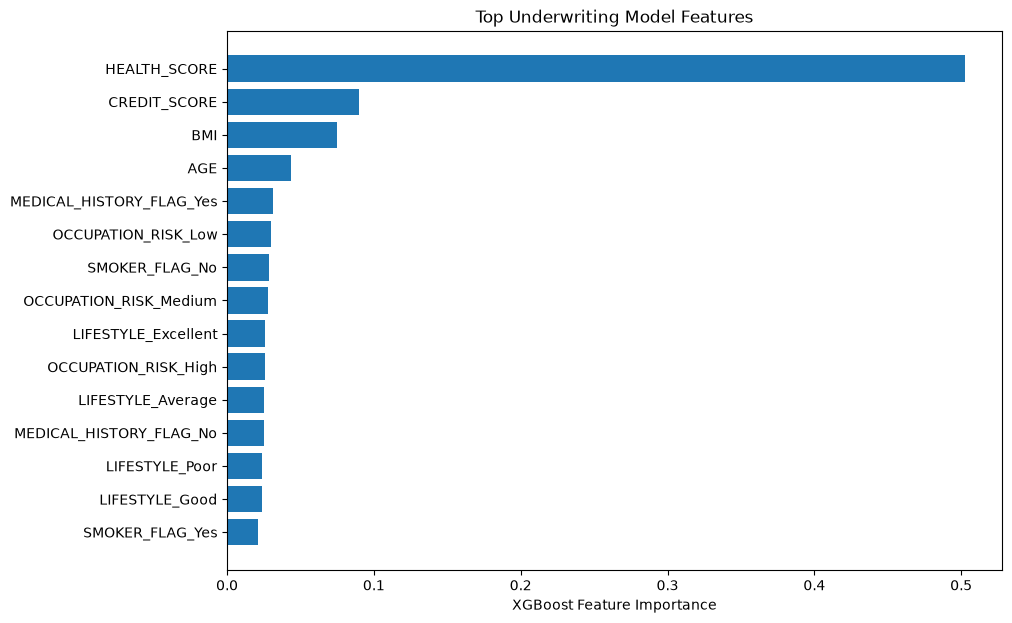

In [20]:
top_features = (
    feature_importance
    .head(15)
    .sort_values(
        "IMPORTANCE"
    )
)

plt.figure(
    figsize=(10, 7)
)

plt.barh(
    top_features[
        "FEATURE"
    ],
    top_features[
        "IMPORTANCE"
    ]
)

plt.title(
    "Top Underwriting Model Features"
)

plt.xlabel(
    "XGBoost Feature Importance"
)

plt.show()

> Feature importance shows predictive usefulness, not causality.  
> The final business decision remains subject to underwriting policy and human review.

## 16. Save underwriting model dataset

In [21]:
underwriting_model_dataset = underwriting_df[
    [
        "UNDERWRITING_ID",
        "POLICY_ID",
        "CUSTOMER_ID",
    ]
    +
    all_features
    +
    [
        "DECISION"
    ]
].copy()

underwriting_model_dataset.to_csv(
    CURATED_DIR
    / "underwriting_model_dataset.csv",
    index=False
)

print(
    "Saved:",
    CURATED_DIR
    / "underwriting_model_dataset.csv"
)

print(
    "Shape:",
    underwriting_model_dataset.shape
)

Saved: f:\insurance_ai_copilot\data\curated\underwriting_model_dataset.csv
Shape: (50000, 12)


## 17. Save production artifacts

In [22]:
# XGBoost is the intended production candidate.
# Replace this if your comparison shows another model is materially better.

best_model = xgb_pipeline


joblib.dump(
    best_model,
    MODELS_DIR
    / "underwriting_xgboost_model.joblib"
)


joblib.dump(
    label_encoder,
    MODELS_DIR
    / "underwriting_label_encoder.joblib"
)


print(
    "Saved underwriting model:",
    MODELS_DIR
    / "underwriting_xgboost_model.joblib"
)

print(
    "Saved label encoder:",
    MODELS_DIR
    / "underwriting_label_encoder.joblib"
)

Saved underwriting model: f:\insurance_ai_copilot\models\underwriting_xgboost_model.joblib
Saved label encoder: f:\insurance_ai_copilot\models\underwriting_label_encoder.joblib


## 18. Reload and validate artifacts

In [23]:
loaded_model = joblib.load(
    MODELS_DIR
    / "underwriting_xgboost_model.joblib"
)

loaded_encoder = joblib.load(
    MODELS_DIR
    / "underwriting_label_encoder.joblib"
)


print(
    "Loaded model type:",
    type(
        loaded_model
    )
)

print(
    "Classes:",
    list(
        loaded_encoder.classes_
    )
)

print(
    "Model input features:"
)

print(
    list(
        loaded_model.feature_names_in_
    )
)

Loaded model type: <class 'sklearn.pipeline.Pipeline'>
Classes: ['Approved', 'Approved with Loading', 'Declined']
Model input features:
['AGE', 'HEALTH_SCORE', 'BMI', 'CREDIT_SCORE', 'LIFESTYLE', 'MEDICAL_HISTORY_FLAG', 'SMOKER_FLAG', 'OCCUPATION_RISK']


## 19. Test one real underwriting case

In [24]:
sample_X = X_test.iloc[
    [0]
]

probabilities = (
    loaded_model
    .predict_proba(
        sample_X
    )[0]
)

predicted_class = int(
    np.argmax(
        probabilities
    )
)

decision = (
    loaded_encoder
    .inverse_transform(
        [
            predicted_class
        ]
    )[0]
)

probability_dict = {
    class_name:
        round(
            float(probability),
            4
        )

    for class_name, probability
    in zip(
        loaded_encoder.classes_,
        probabilities
    )
}


print(
    "Predicted decision:",
    decision
)

print(
    "Probabilities:"
)

print(
    probability_dict
)

print()
print(
    "Important: this is decision support. "
    "Loaded/declined cases will later require human underwriting review."
)

Predicted decision: Approved
Probabilities:
{'Approved': 0.9854, 'Approved with Loading': 0.0133, 'Declined': 0.0013}

Important: this is decision support. Loaded/declined cases will later require human underwriting review.


# Stage 14 Complete

After successful execution:

```text
models/
├── renewal_xgboost_model.joblib
├── renewal_churn_threshold.joblib
├── fraud_xgboost_model.joblib
├── fraud_threshold.joblib
├── underwriting_xgboost_model.joblib
└── underwriting_label_encoder.joblib

data/curated/
└── underwriting_model_dataset.csv
```

Next run `15_model_artifact_validation.ipynb`.